
<style>
:root{
  --blue:#2563eb;
  --indigo:#4f46e5;
  --slate:#334155;
  --muted:#64748b;
  --border:#dbe3ef;
  --soft:#f8fafc;
  --green:#16a34a;
  --amber:#d97706;
  --red:#dc2626;
}
.jp-RenderedHTMLCommon table, .jp-RenderedHTMLCommon th, .jp-RenderedHTMLCommon td {
  border-color:#d7dee8 !important;
}
.note-card{
  border:1px solid var(--border);
  border-radius:18px;
  padding:18px 20px;
  background:linear-gradient(135deg,#ffffff 0%,#f8fbff 100%);
  box-shadow:0 10px 26px rgba(0,0,0,.05);
  margin:12px 0;
}
.metric-chip{
  display:inline-block;
  margin:6px 8px 6px 0;
  padding:8px 14px;
  border-radius:999px;
  background:#eff6ff;
  color:#1d4ed8;
  font-weight:600;
  border:1px solid #bfdbfe;
}
</style>



<div style="display:flex; justify-content:center; margin-top:8px; margin-bottom:18px;">
  <div style="
      max-width:1100px;
      width:100%;
      border:1px solid #d1d5db;
      border-radius:22px;
      padding:34px 42px;
      background:linear-gradient(135deg, #f8fafc 0%, #eff6ff 42%, #f0fdf4 100%);
      box-shadow:0 12px 30px rgba(0,0,0,0.06);
      font-family:Segoe UI, Arial, sans-serif;
  ">
    <div style="text-align:center;">
      <div style="font-size:14px; letter-spacing:1.2px; color:#2563eb; font-weight:700;">UNIVERSIDAD DEL VALLE DE GUATEMALA</div>
      <h1 style="margin:10px 0 6px 0; font-size:34px; color:#0f172a;">Proyecto Final · Inteligencia Artificial</h1>
      <h2 style="margin:0; font-size:22px; color:#334155;">Sistema Inteligente Híbrido para Planificación Académica</h2>
      <p style="margin-top:18px; color:#475569; font-size:16px;">
        Predicción educativa con <b>OULAD</b>, generación de horarios con <b>CSP</b>,
        evaluación probabilística del riesgo y replanificación con <b>MDP</b>.
      </p>
    </div>
    <div style="display:grid; grid-template-columns:1fr 1fr; gap:14px; margin-top:24px;">
      <div style="background:white; border:1px solid #e5e7eb; border-radius:14px; padding:14px;">
        <b>Curso:</b> CC3045 · Inteligencia Artificial<br/>
        <b>Docente:</b> Ing. Alberto Suriano<br/>
        <b>Semestre:</b> I, 2026
      </div>
      <div style="background:white; border:1px solid #e5e7eb; border-radius:14px; padding:14px;">
        <b>Estudiantes:</b> Pablo Daniel Barillas Moreno y Hugo Daniel Barillas Ajín<br/>
        <b>Carnés:</b> 22193 y 23556<br/>
        <b>Entrega:</b> Notebook ejecutable <code>.ipynb</code>
      </div>
    </div>
  </div>
</div>

<p align="center">
  <img src="proyecto_assets/hero_banner.png" width="980"/>
</p>

<div class="note-card">
<b>Resumen.</b> Este notebook implementa el proyecto en cuatro capas:

(1) un módulo de <b>aprendizaje supervisado</b> para identificar estudiantes en riesgo,

(2) un módulo de <b>estimación de demanda académica</b> por curso,

(3) un generador de horarios con <b>Problemas de Satisfacción de Restricciones (CSP)</b> y heurísticas,

y (4) un sistema de <b>toma de decisiones</b> para replanificación bajo incertidumbre usando una red probabilística simplificada y un <b>MDP</b>.
</div>

<div style="text-align:center; margin-bottom:10px;">

  <span class="metric-chip">Machine Learning</span>

  <span class="metric-chip">CSP + MRV + LCV + Forward Checking</span>

  <span class="metric-chip">Razonamiento Bayesiano</span>

  <span class="metric-chip">MDP / Value Iteration</span>

</div>



## Guía

1. **Contexto del problema y formulación matemática**
2. **Carga y preparación del dataset OULAD**
3. **Entrenamiento de modelos predictivos**
4. **Estimación de demanda por módulo**
5. **Generación de horarios con CSP**
6. **Riesgo probabilístico con un modelo bayesiano**
7. **Replanificación adaptativa con MDP**
8. **Conclusiones, limitaciones y trabajo futuro**

<p align="center">
  <img src="proyecto_assets/pipeline.gif" width="920"/>
</p>

<div class="note-card">
<b>Objetivo del proyecto.</b> Integrar múltiples temas del curso en un mismo sistema inteligente:
búsqueda, heurísticas, representación del conocimiento, razonamiento probabilístico, aprendizaje supervisado y toma de decisiones secuenciales.
</div>



# 1. Planteamiento formal del sistema

<div class="note-card">
El problema se modela como un <b>sistema híbrido</b>. El módulo predictivo estima el riesgo académico y la demanda esperada; esa demanda alimenta al módulo CSP para construir el horario; luego, un módulo probabilístico estima el riesgo de conflicto operativo y un MDP sugiere cómo replanificar si ocurre una contingencia.
</div>

## 1.1 Módulo predictivo

Sea $x_i \in \mathbb{R}^d$ el vector de características del estudiante $i$ y $y_i \in \{0,1\}$ la variable objetivo, donde:

- $y_i = 1$ significa **estudiante en riesgo**,
- $y_i = 0$ significa **trayectoria académica favorable**.

Para un clasificador logístico:

$$
P(y_i = 1 \mid x_i) = \sigma(w^\top x_i + b)
\qquad \text{con} \qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

La función de pérdida es:

$$
\mathcal{L}(w,b)= -\frac{1}{n}\sum_{i=1}^{n}
\left[y_i\log(\hat p_i) + (1-y_i)\log(1-\hat p_i)\right].
$$

## 1.2 Módulo de planificación con CSP

Sea $S = \{s_1,\dots,s_m\}$ el conjunto de secciones a programar.  
Cada variable del CSP es una asignación completa:

$$
X_j = (\text{timeslot}_j,\ \text{room}_j,\ \text{professor}_j).
$$

El objetivo es encontrar una asignación factible $x$ que satisfaga todas las restricciones duras y maximice la calidad:

$$
\text{Weight}(x) = \prod_{k=1}^{K} f_k(x),
$$

$$
x^\star = \arg\max_x \text{Weight}(x),
$$

donde $f_k(x)\in\{0,1\}$ para restricciones duras y $f_k(x)\in[0,1]$ para restricciones blandas.

## 1.3 Módulo probabilístico

Usamos una formulación bayesiana simple para estimar el riesgo de conflicto:

$$
P(C \mid E) = \frac{P(E \mid C)\,P(C)}{P(E)},
$$

donde $C$ representa **conflicto operativo** y $E$ es la evidencia observada (alta demanda, poca holgura de salones, escasez docente, etc.).

## 1.4 Módulo MDP

Definimos un proceso de decisión de Markov con estados $s \in \mathcal{S}$, acciones $a \in \mathcal{A}$, recompensas $R(s,a)$ y transiciones $T(s,a,s')$. La ecuación de Bellman para iteración de valor es:

$$
V_{k+1}(s)=\max_a \sum_{s'} T(s,a,s')\left(R(s,a,s') + \gamma V_k(s')\right).
$$

La política óptima es:

$$
\pi^\star(s) = \arg\max_a \sum_{s'} T(s,a,s')\left(R(s,a,s') + \gamma V(s')\right).
$$


In [37]:
# ==========================================================
# 1. Configuración inicial - Instalación de dependencias
# ==========================================================

%pip install -q requests pandas numpy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# =========================
# 2. Configuración inicial
# =========================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import io
import zipfile
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

SEED = 42
np.random.seed(SEED)

# Se buscará OULAD en cualquiera de estas rutas.
DATA_CANDIDATES = [
    Path("data/oulad"),
    Path("data"),
    Path(".")
]

# Ruta preferida de trabajo
DATA_DIR = DATA_CANDIDATES[0]
ASSET_DIR = Path("proyecto_assets")
ASSET_DIR.mkdir(parents=True, exist_ok=True)

In [39]:
# ==========================================
# 3. Carga de OULAD (local, estable y robusta)
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

# Si ya tienes DATA_DIR definido antes, puedes dejarlo.
# Si no, esta línea lo crea por defecto.
DATA_DIR = Path("data/oulad")

def find_oulad_dir():
    """
    Busca una carpeta que contenga studentInfo.csv.
    """
    candidates = [
        Path("data/oulad"),
        Path("data"),
        Path("."),
    ]

    for c in candidates:
        if (c / "studentInfo.csv").exists():
            return c

    raise FileNotFoundError(
        "No se encontró 'studentInfo.csv'. "
        "Coloca los archivos CSV de OULAD en 'data/oulad/', 'data/' o en la carpeta actual."
    )

def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        df = pd.read_csv(path)
        df.columns = [c.strip() for c in df.columns]
        return df
    return None

def load_oulad_base(data_dir=None):
    """
    Carga la tabla base desde studentInfo.csv.
    Debe producir al menos:
    id_student, code_module, code_presentation, final_result y variables demográficas.
    """
    data_dir = find_oulad_dir() if data_dir is None else Path(data_dir)

    student_info = safe_read_csv(data_dir / "studentInfo.csv")
    if student_info is None:
        raise FileNotFoundError(
            f"No se encontró {data_dir / 'studentInfo.csv'}"
        )

    # Limpieza básica
    if "id_student" in student_info.columns:
        student_info["id_student"] = pd.to_numeric(student_info["id_student"], errors="coerce")

    return student_info.copy()

def enrich_with_local_files(base_df, data_dir=None):
    """
    Enriquecimiento opcional usando los CSV locales del dump original de OULAD.
    """
    data_dir = find_oulad_dir() if data_dir is None else Path(data_dir)

    key_cols = ["id_student", "code_module", "code_presentation"]
    df = base_df.copy()

    student_registration = safe_read_csv(data_dir / "studentRegistration.csv")
    student_assessment = safe_read_csv(data_dir / "studentAssessment.csv")
    assessments = safe_read_csv(data_dir / "assessments.csv")
    student_vle = safe_read_csv(data_dir / "studentVle.csv")
    courses = safe_read_csv(data_dir / "courses.csv")

    # ---------------------------------
    # studentRegistration.csv
    # ---------------------------------
    if student_registration is not None:
        reg = student_registration.copy()

        for col in ["id_student", "date_registration", "date_unregistration"]:
            if col in reg.columns:
                reg[col] = pd.to_numeric(reg[col], errors="coerce")

        if "date_unregistration" in reg.columns:
            reg["date_unregistration"] = reg["date_unregistration"].fillna(9999)

        if "date_registration" in reg.columns and "date_unregistration" in reg.columns:
            reg["registration_span"] = reg["date_unregistration"] - reg["date_registration"]

        reg_agg = reg.groupby(key_cols, dropna=False).agg(
            date_registration=("date_registration", "min"),
            registration_span=("registration_span", "mean"),
        ).reset_index()

        df = df.merge(reg_agg, on=key_cols, how="left")

    # ---------------------------------
    # studentAssessment.csv + assessments.csv
    # ---------------------------------
    if (student_assessment is not None) and (assessments is not None):
        sa = student_assessment.copy()
        ass = assessments.copy()

        for col in ["id_assessment", "id_student", "date_submitted", "is_banked", "score"]:
            if col in sa.columns:
                sa[col] = pd.to_numeric(sa[col], errors="coerce")

        for col in ["id_assessment", "date", "weight"]:
            if col in ass.columns:
                ass[col] = pd.to_numeric(ass[col], errors="coerce")

        sa = sa.merge(ass, on="id_assessment", how="left")

        sa_agg = sa.groupby(key_cols, dropna=False).agg(
            n_assessments=("score", "count"),
            avg_score=("score", "mean"),
            std_score=("score", "std"),
            max_score=("score", "max"),
            min_score=("score", "min"),
            avg_submission_day=("date_submitted", "mean"),
            avg_weight=("weight", "mean"),
        ).reset_index()

        df = df.merge(sa_agg, on=key_cols, how="left")

    # ---------------------------------
    # studentVle.csv
    # ---------------------------------
    if student_vle is not None:
        sv = student_vle.copy()

        for col in ["id_student", "id_site", "date", "sum_click"]:
            if col in sv.columns:
                sv[col] = pd.to_numeric(sv[col], errors="coerce")

        sv_agg = sv.groupby(key_cols, dropna=False).agg(
            total_clicks=("sum_click", "sum"),
            active_days=("date", "nunique"),
            avg_clicks_per_day=("sum_click", "mean"),
            n_sites=("id_site", "nunique"),
        ).reset_index()

        df = df.merge(sv_agg, on=key_cols, how="left")

    # ---------------------------------
    # courses.csv
    # ---------------------------------
    if courses is not None:
        crs = courses.copy()

        if "length" in crs.columns:
            crs["length"] = pd.to_numeric(crs["length"], errors="coerce")

        cols = [c for c in ["code_module", "code_presentation", "module_presentation_length", "length"] if c in crs.columns]
        if "code_module" in cols and "code_presentation" in cols:
            df = df.merge(
                crs[cols].drop_duplicates(),
                on=["code_module", "code_presentation"],
                how="left"
            )

    return df

# ---------------------------------
# Ejecutar carga
# ---------------------------------
data_dir = find_oulad_dir()
print("Usando datos desde:", data_dir.resolve())

base_df = load_oulad_base(data_dir)
df = enrich_with_local_files(base_df, data_dir)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

Usando datos desde: C:\Users\Daniel Barillas\Desktop\Proyecto-Final-IA\Proyecto-Final_IA_Seccion_10_Grupo_1\data\oulad
Filas: 32,593
Columnas: 26


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,std_score,max_score,min_score,avg_submission_day,avg_weight,total_clicks,active_days,avg_clicks_per_day,n_sites,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,3.082207,85.0,78.0,112.4,20.0,934.0,40.0,4.765306,55.0,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,4.335897,70.0,60.0,114.2,20.0,1435.0,80.0,3.337209,84.0,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,NaN,NaN,NaN,NaN,281.0,12.0,3.697368,22.0,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,6.892024,88.0,71.0,112.2,20.0,2158.0,123.0,3.254902,82.0,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,20.513410,75.0,30.0,125.6,20.0,1034.0,70.0,2.937500,66.0,268


In [40]:
# ==========================================
# 5. Carga robusta de OULAD (local o descarga)
# ==========================================

OULAD_ZIP_URLS = [
    "https://archive.ics.uci.edu/static/public/349/open%2Buniversity%2Blearning%2Banalytics%2Bdataset.zip",
    "https://analyse.kmi.open.ac.uk/open-dataset/download",
]

REQUIRED_BASE = ["studentInfo.csv"]

def locate_existing_oulad_dir(candidates=DATA_CANDIDATES):
    for candidate in candidates:
        candidate = Path(candidate)
        if all((candidate / f).exists() for f in REQUIRED_BASE):
            return candidate
    return None

def ensure_oulad_files(preferred_dir=DATA_DIR, force_download=False, timeout=60):
    preferred_dir = Path(preferred_dir)
    preferred_dir.mkdir(parents=True, exist_ok=True)

    existing_dir = locate_existing_oulad_dir()
    if existing_dir is not None and not force_download:
        print("✅ Usando archivos locales de OULAD en:", existing_dir.resolve())
        return existing_dir

    last_error = None
    for url in OULAD_ZIP_URLS:
        try:
            print(f"⬇️ Intentando descargar OULAD desde: {url}")
            r = requests.get(url, timeout=timeout)
            r.raise_for_status()

            with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
                csv_members = [m for m in zf.namelist() if m.lower().endswith(".csv")]
                if not csv_members:
                    raise RuntimeError("El ZIP descargado no contiene archivos CSV.")

                for member in csv_members:
                    target_name = Path(member).name
                    with zf.open(member) as src, open(preferred_dir / target_name, "wb") as dst:
                        dst.write(src.read())

            if not (preferred_dir / "studentInfo.csv").exists():
                raise RuntimeError("Se descargó el ZIP, pero no apareció studentInfo.csv")

            print("✅ OULAD descargado y extraído correctamente en:", preferred_dir.resolve())
            return preferred_dir

        except Exception as e:
            last_error = e
            print(f"⚠️ Falló la descarga desde {url}: {e}")

    raise RuntimeError(
        "No se pudo cargar OULAD automáticamente. "
        "Descarga manualmente el ZIP de OULAD y coloca los CSV en ./data/oulad, ./data o el directorio actual. "
        f"Último error: {last_error}"
    )

def safe_read_csv(path):
    path = Path(path)
    if path.exists():
        return pd.read_csv(path, low_memory=False)
    return None

def strip_columns(df):
    if df is not None:
        df.columns = [str(c).strip() for c in df.columns]
    return df

def coerce_numeric(df, columns):
    if df is None:
        return df
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def load_oulad_base_from_csv(data_dir):
    student_info = safe_read_csv(Path(data_dir) / "studentInfo.csv")
    if student_info is None:
        raise FileNotFoundError(
            "No se encontró studentInfo.csv. "
            "Coloca los CSV de OULAD en ./data/oulad, ./data o el directorio actual."
        )
    student_info = strip_columns(student_info)
    return student_info.copy()

def enrich_with_local_files(base_df, data_dir):
    data_dir = Path(data_dir)
    df = base_df.copy()

    sr = strip_columns(safe_read_csv(data_dir / "studentRegistration.csv"))
    sa = strip_columns(safe_read_csv(data_dir / "studentAssessment.csv"))
    sv = strip_columns(safe_read_csv(data_dir / "studentVle.csv"))
    assessments = strip_columns(safe_read_csv(data_dir / "assessments.csv"))
    courses = strip_columns(safe_read_csv(data_dir / "courses.csv"))

    key_cols = ["id_student", "code_module", "code_presentation"]

    if sr is not None:
        sr = coerce_numeric(sr, ["date_registration", "date_unregistration", "id_student"])
        df = df.merge(sr, on=key_cols, how="left")

    if sa is not None:
        sa = coerce_numeric(sa, ["id_assessment", "id_student", "date_submitted", "is_banked", "score"])

        sa_agg = sa.groupby("id_student", dropna=False).agg(
            assessment_score_mean=("score", "mean"),
            assessment_score_std=("score", "std"),
            assessment_score_max=("score", "max"),
            assessment_score_min=("score", "min"),
            assessment_n=("score", "count"),
            assessment_banked_mean=("is_banked", "mean"),
            submitted_date_mean=("date_submitted", "mean")
        ).reset_index()

        df = df.merge(sa_agg, on="id_student", how="left")

        if assessments is not None and "id_assessment" in assessments.columns:
            assessments = coerce_numeric(assessments, ["id_assessment", "date", "weight"])
            sa2 = sa.merge(assessments, on="id_assessment", how="left")

            if "assessment_type" in sa2.columns:
                sa_type = (
                    sa2.groupby(["id_student", "assessment_type"], dropna=False)
                       .agg(type_score_mean=("score", "mean"),
                            type_n=("score", "count"))
                       .reset_index()
                )

                type_score = sa_type.pivot(index="id_student", columns="assessment_type", values="type_score_mean")
                type_count = sa_type.pivot(index="id_student", columns="assessment_type", values="type_n")

                if type_score is not None and not type_score.empty:
                    type_score.columns = [f"score_mean_{str(c).lower()}" for c in type_score.columns]
                    df = df.merge(type_score.reset_index(), on="id_student", how="left")

                if type_count is not None and not type_count.empty:
                    type_count.columns = [f"n_{str(c).lower()}" for c in type_count.columns]
                    df = df.merge(type_count.reset_index(), on="id_student", how="left")

    if sv is not None:
        sv = coerce_numeric(sv, ["id_student", "id_site", "date", "sum_click"])
        sv_agg = sv.groupby(key_cols, dropna=False).agg(
            vle_clicks_sum=("sum_click", "sum"),
            vle_clicks_mean=("sum_click", "mean"),
            vle_clicks_std=("sum_click", "std"),
            vle_days_active=("date", "nunique"),
            vle_sites_n=("id_site", "nunique"),
        ).reset_index()
        df = df.merge(sv_agg, on=key_cols, how="left")

    if courses is not None:
        courses = coerce_numeric(courses, ["length"])
        course_cols = [c for c in ["code_module", "code_presentation", "length"] if c in courses.columns]
        if {"code_module", "code_presentation"}.issubset(course_cols):
            df = df.merge(
                courses[course_cols].drop_duplicates(),
                on=["code_module", "code_presentation"],
                how="left"
            )

    return df

DATA_DIR = ensure_oulad_files()
base_df = load_oulad_base_from_csv(DATA_DIR)
df = enrich_with_local_files(base_df, DATA_DIR)

print(f"Ruta de datos usada: {DATA_DIR.resolve()}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
display(df.head())

✅ Usando archivos locales de OULAD en: C:\Users\Daniel Barillas\Desktop\Proyecto-Final-IA\Proyecto-Final_IA_Seccion_10_Grupo_1\data\oulad


Ruta de datos usada: C:\Users\Daniel Barillas\Desktop\Proyecto-Final-IA\Proyecto-Final_IA_Seccion_10_Grupo_1\data\oulad
Filas: 32,593
Columnas: 32


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,score_mean_exam,score_mean_tma,n_cma,n_exam,n_tma,vle_clicks_sum,vle_clicks_mean,vle_clicks_std,vle_days_active,vle_sites_n
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,NaN,82.0,NaN,NaN,5.0,934.0,4.765306,7.591224,40.0,55.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,NaN,66.4,NaN,NaN,5.0,1435.0,3.337209,3.634240,80.0,84.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,NaN,NaN,NaN,NaN,281.0,3.697368,4.056336,12.0,22.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,NaN,76.0,NaN,NaN,5.0,2158.0,3.254902,3.194577,123.0,82.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,NaN,54.4,NaN,NaN,5.0,1034.0,2.937500,3.261895,70.0,66.0


Valores faltantes por columna (top 15):


,missing
n_exam,26595
score_mean_exam,26595
date_unregistration,22521
n_cma,15649
score_mean_cma,15649
assessment_score_std,7998
score_mean_tma,6633
n_tma,6608
assessment_score_max,5866
assessment_score_min,5866


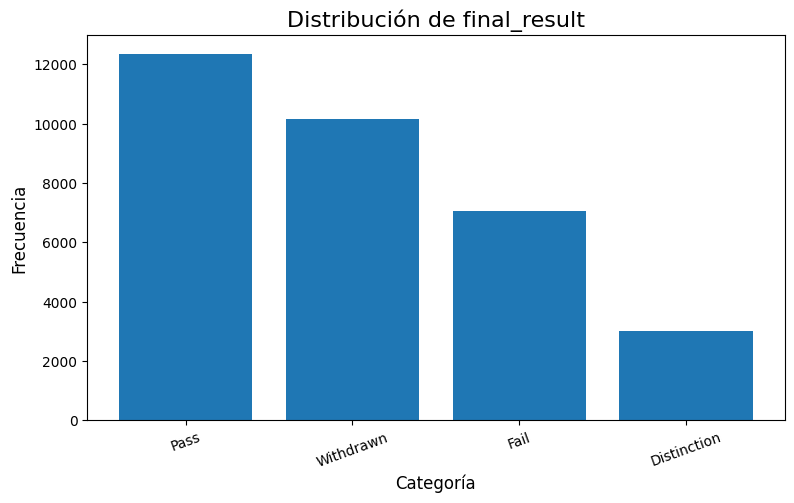

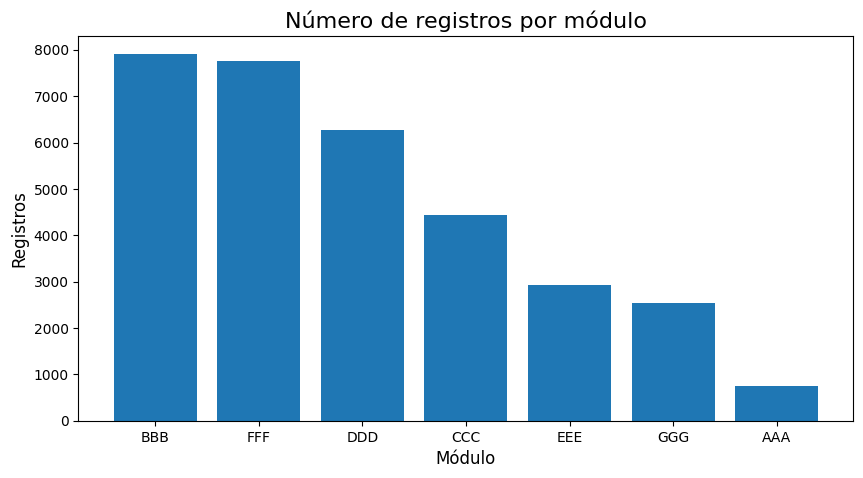

In [41]:
# ==========================================
# 6. EDA básico
# ==========================================

print("Valores faltantes por columna (top 15):")
display(df.isna().sum().sort_values(ascending=False).head(15).to_frame("missing"))

if "final_result" in df.columns:
    result_counts = df["final_result"].astype(str).value_counts().sort_values(ascending=False)
    plt.figure(figsize=(9,5))
    plt.bar(result_counts.index, result_counts.values)
    plt.title("Distribución de final_result")
    plt.xlabel("Categoría")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=20)
    plt.show()

if "code_module" in df.columns:
    module_counts = df["code_module"].astype(str).value_counts().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    plt.bar(module_counts.index, module_counts.values)
    plt.title("Número de registros por módulo")
    plt.xlabel("Módulo")
    plt.ylabel("Registros")
    plt.show()



# 6. Ingeniería de características y definición del target

<div class="note-card">
Para conectar la parte predictiva con el resto del proyecto, transformaremos el resultado final en una variable binaria:
<ul>
  <li><b>At-Risk = 1</b> para estudiantes con resultado adverso o retiro.</li>
  <li><b>At-Risk = 0</b> para estudiantes con trayectoria favorable (Pass / Distinction).</li>
</ul>
</div>

## 6.1 Definición del target

Sea:

$$
y_i =
\begin{cases}
1 & \text{si el estudiante está en riesgo} \\
0 & \text{si el estudiante no está en riesgo}
\end{cases}
$$

Se usarán variables categóricas y numéricas; si el enriquecimiento local está disponible, también se agregarán:

- promedio de calificaciones,
- número de evaluaciones,
- clicks totales en la VLE,
- días activos,
- span de registro,
- día promedio de entrega.


In [42]:
# ==========================================
# 7. Preparación del target y selección de variables
# ==========================================

def make_at_risk_target(series):
    adverse = {"Fail", "Withdrawal", "Withdrawn", "Dropout", "Absent", "No Award"}
    series = series.astype(str).str.strip()
    return series.apply(lambda x: 1 if x in adverse else 0)

work_df = df.copy()
work_df["at_risk"] = make_at_risk_target(work_df["final_result"])

drop_cols = [c for c in ["final_result"] if c in work_df.columns]
model_df = work_df.drop(columns=drop_cols)

id_like = [c for c in ["id_student"] if c in model_df.columns]
feature_df = model_df.drop(columns=id_like, errors="ignore")

categorical_cols = [c for c in feature_df.columns if feature_df[c].dtype == "object" and c != "at_risk"]
numeric_cols = [c for c in feature_df.columns if c not in categorical_cols + ["at_risk"]]

X = feature_df.drop(columns=["at_risk"])
y = feature_df["at_risk"]

print(f"Número de observaciones: {len(X):,}")
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numeric_cols)}")

display(X.head())


Número de observaciones: 32,593
Variables categóricas: 8
Variables numéricas: 22


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,score_mean_exam,score_mean_tma,n_cma,n_exam,n_tma,vle_clicks_sum,vle_clicks_mean,vle_clicks_std,vle_days_active,vle_sites_n
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,NaN,82.0,NaN,NaN,5.0,934.0,4.765306,7.591224,40.0,55.0
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,NaN,66.4,NaN,NaN,5.0,1435.0,3.337209,3.634240,80.0,84.0
2,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,...,NaN,NaN,NaN,NaN,NaN,281.0,3.697368,4.056336,12.0,22.0
3,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,NaN,76.0,NaN,NaN,5.0,2158.0,3.254902,3.194577,123.0,82.0
4,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,...,NaN,54.4,NaN,NaN,5.0,1034.0,2.937500,3.261895,70.0,66.0


In [43]:
# ==========================================
# 7. Preparación del target y selección de variables
# ==========================================

def make_at_risk_target(series):
    adverse = {"Fail", "Withdrawal", "Withdrawn", "Dropout", "Absent", "No Award"}
    series = series.astype(str).str.strip()
    return series.apply(lambda x: 1 if x in adverse else 0)

work_df = df.copy()
work_df["at_risk"] = make_at_risk_target(work_df["final_result"])

drop_cols = [c for c in ["final_result"] if c in work_df.columns]
model_df = work_df.drop(columns=drop_cols, errors="ignore")

# Se eliminan identificadores directos para evitar leakage.
id_like = [c for c in ["id_student"] if c in model_df.columns]
feature_df = model_df.drop(columns=id_like, errors="ignore")

categorical_cols = [
    c for c in feature_df.columns
    if str(feature_df[c].dtype) in {"object", "category"} and c != "at_risk"
]
numeric_cols = [c for c in feature_df.columns if c not in categorical_cols + ["at_risk"]]

X = feature_df.drop(columns=["at_risk"])
y = feature_df["at_risk"].astype(int)

print(f"Número de observaciones: {len(X):,}")
print(f"Variables categóricas: {len(categorical_cols)}")
print(f"Variables numéricas: {len(numeric_cols)}")
print("Distribución del target:")
display(y.value_counts(dropna=False).rename_axis("at_risk").to_frame("count"))

display(X.head())

Número de observaciones: 32,593
Variables categóricas: 8
Variables numéricas: 22
Distribución del target:


,count
at_risk,
1,17208
0,15385


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,score_mean_exam,score_mean_tma,n_cma,n_exam,n_tma,vle_clicks_sum,vle_clicks_mean,vle_clicks_std,vle_days_active,vle_sites_n
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,NaN,82.0,NaN,NaN,5.0,934.0,4.765306,7.591224,40.0,55.0
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,NaN,66.4,NaN,NaN,5.0,1435.0,3.337209,3.634240,80.0,84.0
2,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,...,NaN,NaN,NaN,NaN,NaN,281.0,3.697368,4.056336,12.0,22.0
3,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,NaN,76.0,NaN,NaN,5.0,2158.0,3.254902,3.194577,123.0,82.0
4,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,...,NaN,54.4,NaN,NaN,5.0,1034.0,2.937500,3.261895,70.0,66.0


In [44]:
# ==========================================
# 8. Pipelines y entrenamiento
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=SEED),
}

trained_models = {}
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    try:
        y_score = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = np.nan

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": auc
    })

X_train_dense = preprocessor.fit_transform(X_train)
X_test_dense = preprocessor.transform(X_test)

if hasattr(X_train_dense, "toarray"):
    X_train_dense = X_train_dense.toarray()
    X_test_dense = X_test_dense.toarray()

gnb = GaussianNB()
gnb.fit(X_train_dense, y_train)
trained_models["GaussianNB"] = ("dense_nb", gnb)

y_pred_nb = gnb.predict(X_test_dense)
y_score_nb = gnb.predict_proba(X_test_dense)[:, 1]

results.append({
    "model": "GaussianNB",
    "accuracy": accuracy_score(y_test, y_pred_nb),
    "precision": precision_score(y_test, y_pred_nb, zero_division=0),
    "recall": recall_score(y_test, y_pred_nb, zero_division=0),
    "f1": f1_score(y_test, y_pred_nb, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score_nb)
})

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)


,model,accuracy,precision,recall,f1,roc_auc
0,DecisionTree,0.937170,0.963325,0.915853,0.938990,0.972385
1,MLPClassifier,0.923181,0.924873,0.930033,0.927446,0.974341
2,LogisticRegression,0.876304,0.891583,0.871688,0.881523,0.949817
3,GaussianNB,0.858510,0.960515,0.763366,0.850667,0.939949


In [45]:
# ==========================================
# 8. Pipelines y entrenamiento
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=SEED),
}

trained_models = {}
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    try:
        y_score = pipe.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except Exception:
        auc = np.nan

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": auc
    })

# GaussianNB requiere una matriz densa; se entrena con un preprocesador aparte
nb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

X_train_nb = nb_preprocessor.fit_transform(X_train)
X_test_nb = nb_preprocessor.transform(X_test)

if hasattr(X_train_nb, "toarray"):
    X_train_nb = X_train_nb.toarray()
    X_test_nb = X_test_nb.toarray()

gnb = GaussianNB()
gnb.fit(X_train_nb, y_train)
trained_models["GaussianNB"] = {"preprocessor": nb_preprocessor, "model": gnb}

y_pred_nb = gnb.predict(X_test_nb)
y_score_nb = gnb.predict_proba(X_test_nb)[:, 1]

results.append({
    "model": "GaussianNB",
    "accuracy": accuracy_score(y_test, y_pred_nb),
    "precision": precision_score(y_test, y_pred_nb, zero_division=0),
    "recall": recall_score(y_test, y_pred_nb, zero_division=0),
    "f1": f1_score(y_test, y_pred_nb, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_score_nb)
})

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,precision,recall,f1,roc_auc
0,DecisionTree,0.937170,0.963325,0.915853,0.938990,0.972385
1,MLPClassifier,0.923181,0.924873,0.930033,0.927446,0.974341
2,LogisticRegression,0.876304,0.891583,0.871688,0.881523,0.949817
3,GaussianNB,0.858510,0.960515,0.763366,0.850667,0.939949


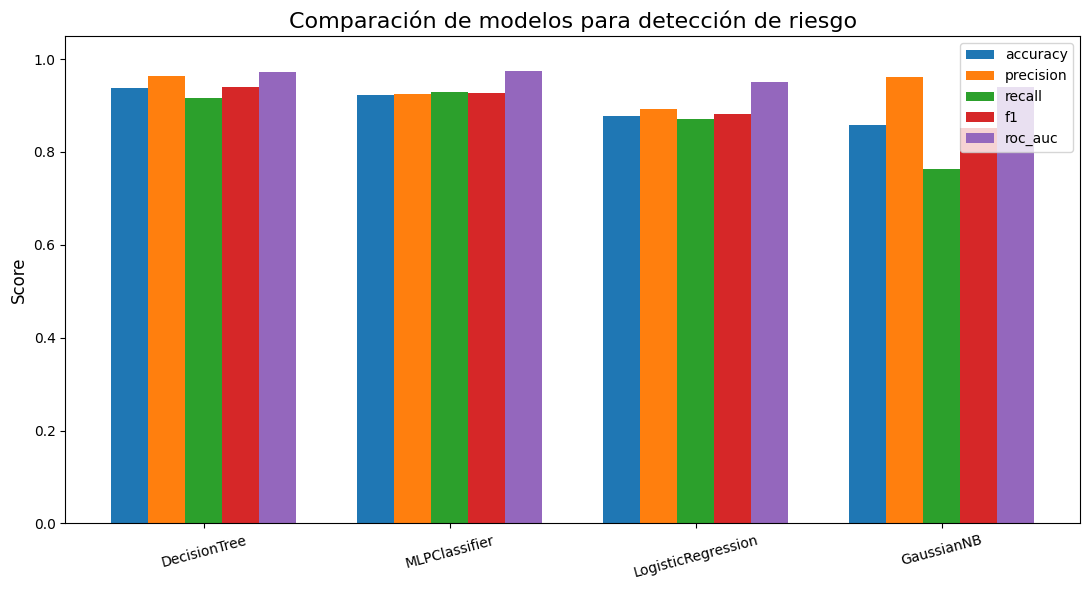

Mejor modelo según F1: DecisionTree


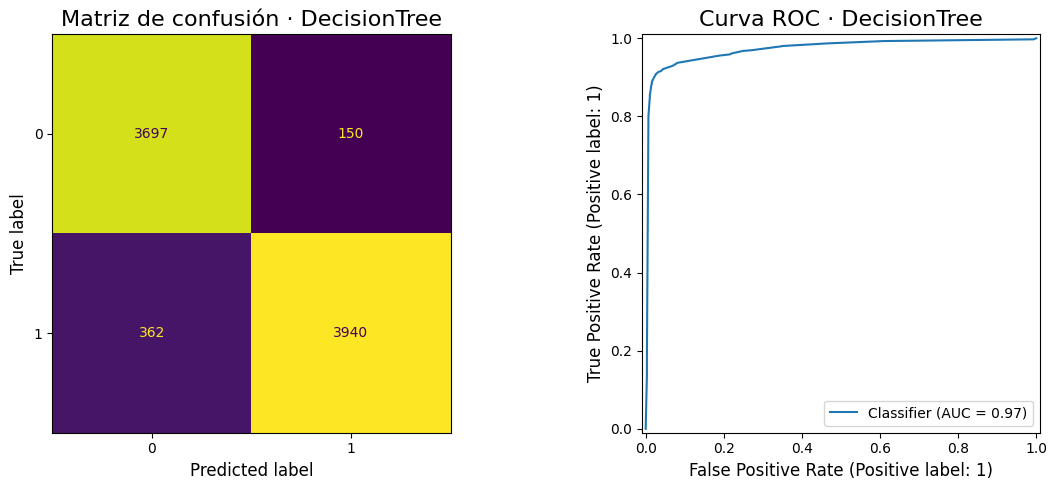

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      3847
           1       0.96      0.92      0.94      4302

    accuracy                           0.94      8149
   macro avg       0.94      0.94      0.94      8149
weighted avg       0.94      0.94      0.94      8149



In [46]:
# ==========================================
# 9. Visualización de desempeño
# ==========================================

metric_names = ["accuracy", "precision", "recall", "f1", "roc_auc"]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metric_names):
    ax.bar(x + i * width, results_df[metric].fillna(0), width=width, label=metric)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df["model"], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title("Comparación de modelos para detección de riesgo")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["model"]
print(f"Mejor modelo según F1: {best_model_name}")

if best_model_name == "GaussianNB":
    y_pred_best = gnb.predict(X_test_nb)
    y_score_best = gnb.predict_proba(X_test_nb)[:, 1]
else:
    best_pipe = trained_models[best_model_name]
    y_pred_best = best_pipe.predict(X_test)
    y_score_best = best_pipe.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[0], colorbar=False)
axes[0].set_title(f"Matriz de confusión · {best_model_name}")
RocCurveDisplay.from_predictions(y_test, y_score_best, ax=axes[1])
axes[1].set_title(f"Curva ROC · {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, zero_division=0))

,code_module,students,expected_active,mean_risk,sections_needed
0,BBB,7909,3783.588045,0.521610,109
1,FFF,7762,3708.007086,0.522287,106
2,DDD,6272,2600.439406,0.585389,75
3,CCC,4434,1685.016869,0.619978,49
4,EEE,2934,1599.817359,0.454732,46
5,GGG,2534,1514.258845,0.402424,44
6,AAA,748,504.072651,0.326106,15


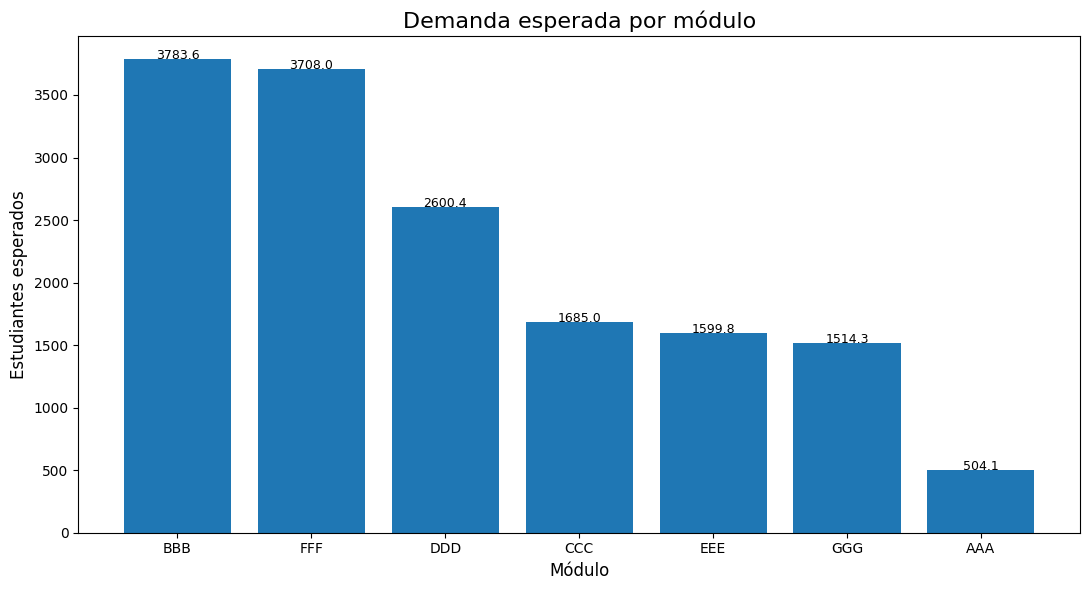

In [47]:
# ==========================================
# 10. Estimación de demanda por módulo
# ==========================================

full_X = X.copy()

if best_model_name == "GaussianNB":
    X_dense_full = preprocessor.fit_transform(full_X)
    if hasattr(X_dense_full, "toarray"):
        X_dense_full = X_dense_full.toarray()
    risk_proba = gnb.fit(X_train_dense, y_train).predict_proba(X_dense_full)[:, 1]
else:
    best_pipe = trained_models[best_model_name]
    risk_proba = best_pipe.predict_proba(full_X)[:, 1]

demand_df = work_df.loc[full_X.index, ["code_module", "code_presentation"]].copy()
demand_df["risk_proba"] = risk_proba
demand_df["success_proba"] = 1 - demand_df["risk_proba"]

module_summary = demand_df.groupby("code_module").agg(
    students=("success_proba", "size"),
    expected_active=("success_proba", "sum"),
    mean_risk=("risk_proba", "mean"),
).reset_index()

TARGET_SECTION_SIZE = 35
module_summary["sections_needed"] = np.ceil(module_summary["expected_active"] / TARGET_SECTION_SIZE).astype(int)
module_summary = module_summary.sort_values(["expected_active", "mean_risk"], ascending=[False, True]).reset_index(drop=True)

display(module_summary.head(10))

top_modules = module_summary.head(8).copy()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(top_modules["code_module"], top_modules["expected_active"])
ax1.set_title("Demanda esperada por módulo")
ax1.set_xlabel("Módulo")
ax1.set_ylabel("Estudiantes esperados")
for i, v in enumerate(top_modules["expected_active"]):
    ax1.text(i, v + 1, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


,code_module,students,expected_active,mean_risk,scaled_expected_active,sections_needed
0,BBB,7909,3783.588045,0.521610,44,2
1,FFF,7762,3708.007086,0.522287,43,2
2,DDD,6272,2600.439406,0.585389,30,2
3,CCC,4434,1685.016869,0.619978,20,1
4,EEE,2934,1599.817359,0.454732,19,1
5,GGG,2534,1514.258845,0.402424,18,1
6,AAA,748,504.072651,0.326106,12,1


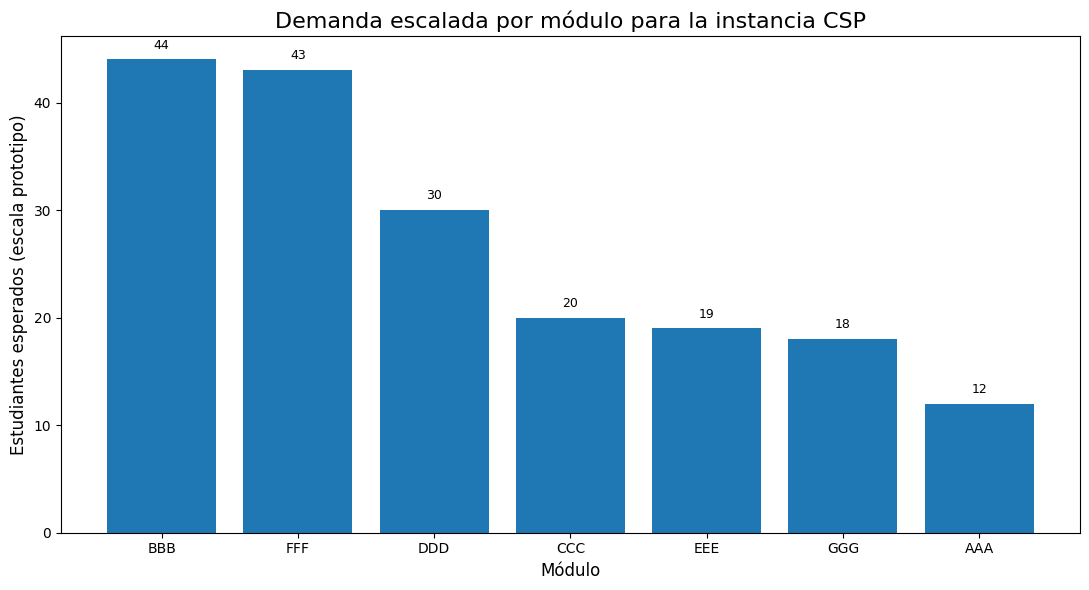

In [48]:
# ==========================================
# 10. Estimación de demanda por módulo
# ==========================================

full_X = X.copy()

if best_model_name == "GaussianNB":
    X_full_nb = nb_preprocessor.transform(full_X)
    if hasattr(X_full_nb, "toarray"):
        X_full_nb = X_full_nb.toarray()
    risk_proba = gnb.predict_proba(X_full_nb)[:, 1]
else:
    best_pipe = trained_models[best_model_name]
    risk_proba = best_pipe.predict_proba(full_X)[:, 1]

demand_df = work_df.loc[full_X.index, ["code_module", "code_presentation"]].copy()
demand_df["risk_proba"] = risk_proba
demand_df["success_proba"] = 1 - demand_df["risk_proba"]

module_summary = demand_df.groupby("code_module").agg(
    students=("success_proba", "size"),
    expected_active=("success_proba", "sum"),
    mean_risk=("risk_proba", "mean"),
).reset_index()

# Escalado a una facultad prototipo para que el CSP sea resoluble en notebook.
PLANNING_TOTAL_STUDENTS = 180
TARGET_SECTION_SIZE = 28
MAX_SECTIONS_PER_MODULE = 4

total_expected = module_summary["expected_active"].sum()
module_summary["scaled_expected_active"] = np.maximum(
    12,
    np.round(module_summary["expected_active"] / total_expected * PLANNING_TOTAL_STUDENTS)
).astype(int)

module_summary["sections_needed"] = np.ceil(
    module_summary["scaled_expected_active"] / TARGET_SECTION_SIZE
).astype(int).clip(1, MAX_SECTIONS_PER_MODULE)

module_summary = module_summary.sort_values(
    ["scaled_expected_active", "mean_risk"],
    ascending=[False, True]
).reset_index(drop=True)

display(module_summary.head(10))

top_modules = module_summary.head(8).copy()

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(top_modules["code_module"], top_modules["scaled_expected_active"])
ax1.set_title("Demanda escalada por módulo para la instancia CSP")
ax1.set_xlabel("Módulo")
ax1.set_ylabel("Estudiantes esperados (escala prototipo)")
for i, v in enumerate(top_modules["scaled_expected_active"]):
    ax1.text(i, v + 1, f"{int(v)}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [49]:
# ==========================================
# 11. Construcción de una instancia CSP
# ==========================================

from itertools import product

rooms = [
    {"room": "A-101", "capacity": 30},
    {"room": "A-102", "capacity": 35},
    {"room": "B-201", "capacity": 40},
    {"room": "B-202", "capacity": 45},
    {"room": "LAB-1", "capacity": 28},
    {"room": "LAB-2", "capacity": 32},
]

days = ["Lun", "Mar", "Mie", "Jue", "Vie"]
hours = ["07:00", "09:00", "11:00", "14:00"]
timeslots = [f"{d}-{h}" for d in days for h in hours]

module_list = top_modules["code_module"].tolist()
professors = [
    {"name": "Prof_A", "modules": module_list[:4]},
    {"name": "Prof_B", "modules": module_list[2:6]},
    {"name": "Prof_C", "modules": module_list[1:5]},
    {"name": "Prof_D", "modules": module_list[4:8]},
    {"name": "Prof_E", "modules": module_list[:3] + module_list[-2:]},
    {"name": "Prof_F", "modules": module_list[3:]},
]

preferred_morning = {"Prof_A", "Prof_C", "Prof_E"}

sections = []
for _, row in top_modules.iterrows():
    n_sections = int(max(1, row["sections_needed"]))
    students_per_section = int(np.ceil(row["expected_active"] / n_sections))
    for k in range(n_sections):
        section_id = f"{row['code_module']}-S{k+1}"
        sections.append({
            "section": section_id,
            "module": row["code_module"],
            "students": students_per_section
        })

sections_df = pd.DataFrame(sections)
display(sections_df.head(10))
print(f"Total de secciones a programar: {len(sections_df)}")


,section,module,students
0,BBB-S1,BBB,1892
1,BBB-S2,BBB,1892
2,FFF-S1,FFF,1855
3,FFF-S2,FFF,1855
4,DDD-S1,DDD,1301
5,DDD-S2,DDD,1301
6,CCC-S1,CCC,1686
7,EEE-S1,EEE,1600
8,GGG-S1,GGG,1515
9,AAA-S1,AAA,505


Total de secciones a programar: 10


In [50]:
# ==========================================
# 11. Construcción de una instancia CSP
# ==========================================

rooms = [
    {"room": "A-101", "capacity": 30},
    {"room": "A-102", "capacity": 35},
    {"room": "B-201", "capacity": 40},
    {"room": "B-202", "capacity": 45},
    {"room": "LAB-1", "capacity": 28},
    {"room": "LAB-2", "capacity": 32},
]

days = ["Lun", "Mar", "Mie", "Jue", "Vie"]
hours = ["07:00", "09:00", "11:00", "14:00"]
timeslots = [f"{d}-{h}" for d in days for h in hours]

module_list = top_modules["code_module"].tolist()
professors = [
    {"name": "Prof_A", "modules": module_list[:4]},
    {"name": "Prof_B", "modules": module_list[2:6]},
    {"name": "Prof_C", "modules": module_list[1:5]},
    {"name": "Prof_D", "modules": module_list[4:8]},
    {"name": "Prof_E", "modules": module_list[:3] + module_list[-2:]},
    {"name": "Prof_F", "modules": module_list[3:]},
]

preferred_morning = {"Prof_A", "Prof_C", "Prof_E"}

sections = []
for _, row in top_modules.iterrows():
    n_sections = int(max(1, row["sections_needed"]))
    students_per_section = int(np.ceil(row["scaled_expected_active"] / n_sections))
    for k in range(n_sections):
        section_id = f"{row['code_module']}-S{k+1}"
        sections.append({
            "section": section_id,
            "module": row["code_module"],
            "students": students_per_section
        })

sections_df = pd.DataFrame(sections)
display(sections_df.head(10))
print(f"Total de secciones a programar: {len(sections_df)}")

,section,module,students
0,BBB-S1,BBB,22
1,BBB-S2,BBB,22
2,FFF-S1,FFF,22
3,FFF-S2,FFF,22
4,DDD-S1,DDD,15
5,DDD-S2,DDD,15
6,CCC-S1,CCC,20
7,EEE-S1,EEE,19
8,GGG-S1,GGG,18
9,AAA-S1,AAA,12


Total de secciones a programar: 10


In [51]:
# ==========================================
# 12. CSP Solver con MRV + LCV + Forward Checking
#     (versión corregida y escalable)
# ==========================================

from collections import defaultdict

MAX_SECTIONS = min(30, len(sections_df))   # seguridad adicional
TOP_K_DOMAIN = 25                          # recorte del dominio por sección
LCV_NEIGHBOR_SAMPLE = 12                   # vecinos a revisar en LCV
LCV_VALUE_SAMPLE = 20                      # valores a ordenar por LCV

def professor_candidates(module):
    return [p["name"] for p in professors if module in p["modules"]]

def soft_score(value):
    slot, room, prof = value
    score = 0
    if prof in preferred_morning and any(h in slot for h in ["07:00", "09:00"]):
        score += 2
    if room.startswith("LAB") and prof in {"Prof_B", "Prof_D"}:
        score += 1
    return score

def feasible_domain(section_row):
    profs = professor_candidates(section_row["module"])
    feasible_rooms = [r["room"] for r in rooms if r["capacity"] >= section_row["students"]]
    raw_domain = list(product(timeslots, feasible_rooms, profs))
    raw_domain.sort(key=lambda v: -soft_score(v))
    return raw_domain[:TOP_K_DOMAIN]

sections_work = (
    sections_df.sort_values(by="students", ascending=False)
               .head(MAX_SECTIONS)
               .reset_index(drop=True)
               .copy()
)

section_dict = {row["section"]: row for _, row in sections_work.iterrows()}
domains = {sec: feasible_domain(row) for sec, row in section_dict.items()}

empty_domains = [sec for sec, dom in domains.items() if len(dom) == 0]
if empty_domains:
    raise ValueError(f"Estas secciones quedaron con dominio vacío: {empty_domains}")

section_prof_candidates = {
    sec: set(professor_candidates(row["module"]))
    for sec, row in section_dict.items()
}

section_room_candidates = {
    sec: set(r["room"] for r in rooms if r["capacity"] >= row["students"])
    for sec, row in section_dict.items()
}

neighbors = {sec: set() for sec in section_dict}
secs = list(section_dict.keys())
for i in range(len(secs)):
    for j in range(i + 1, len(secs)):
        s1, s2 = secs[i], secs[j]
        share_prof = len(section_prof_candidates[s1] & section_prof_candidates[s2]) > 0
        share_room = len(section_room_candidates[s1] & section_room_candidates[s2]) > 0
        if share_prof or share_room:
            neighbors[s1].add(s2)
            neighbors[s2].add(s1)

def is_consistent_fast(slot, room, prof, used_room_slot, used_prof_slot):
    return (slot, room) not in used_room_slot and (slot, prof) not in used_prof_slot

def select_unassigned_variable(assignment, domains, neighbors):
    unassigned = [s for s in domains if s not in assignment]
    return min(unassigned, key=lambda s: (len(domains[s]), -len(neighbors[s])))

def lcv_order(section, assignment, domains, neighbors, used_room_slot, used_prof_slot):
    candidate_values = domains[section][:LCV_VALUE_SAMPLE]
    neighs = [n for n in neighbors[section] if n not in assignment][:LCV_NEIGHBOR_SAMPLE]

    scored = []
    for value in candidate_values:
        slot, room, prof = value

        if not is_consistent_fast(slot, room, prof, used_room_slot, used_prof_slot):
            continue

        penalty = 0
        for neigh in neighs:
            invalidated = 0
            for v2 in domains[neigh]:
                s2, r2, p2 = v2
                if (slot == s2 and room == r2) or (slot == s2 and prof == p2):
                    invalidated += 1
            penalty += invalidated

        scored.append((value, penalty, -soft_score(value)))

    scored.sort(key=lambda x: (x[1], x[2]))
    return [v for v, _, _ in scored]

def forward_check(section, value, assignment, domains, neighbors):
    slot, room, prof = value

    new_domains = {k: list(v) for k, v in domains.items()}
    new_domains[section] = [value]

    for other in neighbors[section]:
        if other in assignment or other == section:
            continue

        filtered = []
        for v in new_domains[other]:
            s2, r2, p2 = v
            if not ((slot == s2 and room == r2) or (slot == s2 and prof == p2)):
                filtered.append(v)

        if not filtered:
            return None

        new_domains[other] = filtered

    return new_domains

def backtracking_search(
    assignment,
    domains,
    neighbors,
    used_room_slot,
    used_prof_slot,
    counter
):
    if len(assignment) == len(domains):
        return assignment.copy()

    section = select_unassigned_variable(assignment, domains, neighbors)
    ordered_values = lcv_order(section, assignment, domains, neighbors, used_room_slot, used_prof_slot)

    for value in ordered_values:
        slot, room, prof = value

        if is_consistent_fast(slot, room, prof, used_room_slot, used_prof_slot):
            new_domains = forward_check(section, value, assignment, domains, neighbors)
            if new_domains is not None:
                assignment[section] = value
                used_room_slot.add((slot, room))
                used_prof_slot.add((slot, prof))

                result = backtracking_search(
                    assignment,
                    new_domains,
                    neighbors,
                    used_room_slot,
                    used_prof_slot,
                    counter
                )

                if result is not None:
                    return result

                del assignment[section]
                used_room_slot.remove((slot, room))
                used_prof_slot.remove((slot, prof))

        counter["backtracks"] += 1

    return None

counter = {"backtracks": 0}
used_room_slot = set()
used_prof_slot = set()

start = time.perf_counter()
solution = backtracking_search(
    assignment={},
    domains=domains,
    neighbors=neighbors,
    used_room_slot=used_room_slot,
    used_prof_slot=used_prof_slot,
    counter=counter
)
end = time.perf_counter()

print("Backtracks:", counter["backtracks"])
print("¿Se encontró solución?", solution is not None)
print(f"Tiempo total: {end - start:.4f} segundos")

Backtracks: 0
¿Se encontró solución? True
Tiempo total: 0.0024 segundos


# Diagnóstico del CSP construido

In [52]:
domain_sizes = [len(v) for v in domains.values()]
print("Secciones consideradas por el solver:", len(domains))
print("Dominio promedio:", round(sum(domain_sizes) / len(domain_sizes), 2))
print("Dominio máximo:", max(domain_sizes))
print("Dominio mínimo:", min(domain_sizes))

Secciones consideradas por el solver: 10
Dominio promedio: 25.0
Dominio máximo: 25
Dominio mínimo: 25


,section,module,day,hour,room,professor,students
0,FFF-S2,FFF,Lun,07:00,A-101,Prof_A,22
1,DDD-S1,DDD,Lun,07:00,A-102,Prof_C,15
2,DDD-S2,DDD,Lun,07:00,B-201,Prof_E,15
3,FFF-S1,FFF,Lun,09:00,A-101,Prof_E,22
4,BBB-S1,BBB,Lun,09:00,B-201,Prof_A,22
5,CCC-S1,CCC,Lun,09:00,B-202,Prof_C,20
6,BBB-S2,BBB,Mar,07:00,A-101,Prof_A,22
7,EEE-S1,EEE,Mar,07:00,A-102,Prof_C,19
8,AAA-S1,AAA,Mar,07:00,B-201,Prof_E,12
9,GGG-S1,GGG,Mie,07:00,A-101,Prof_E,18


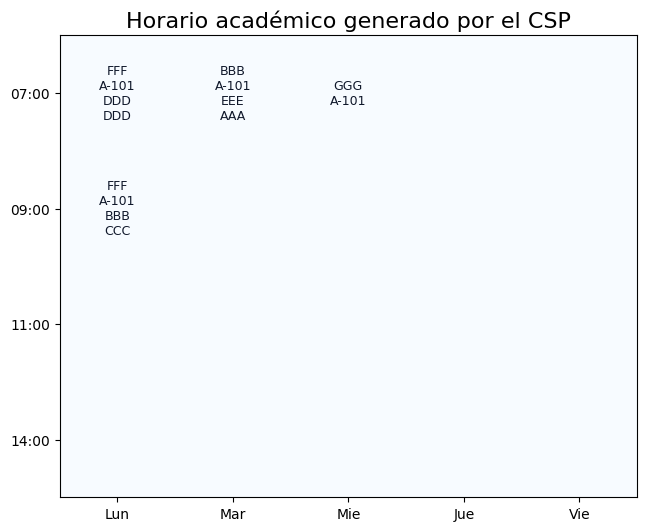

,secciones_asignadas
professor,
Prof_A,3
Prof_C,3
Prof_E,4


In [53]:
# ==========================================
# 13. Visualización del horario generado
# ==========================================

if solution is None:
    raise RuntimeError(
        "No se encontró una solución factible con la instancia actual. "
        "Reduce MAX_SECTIONS o TOP_K_DOMAIN, o aumenta la capacidad / disponibilidad."
    )

schedule_rows = []
for sec, (slot, room, prof) in solution.items():
    module = section_dict[sec]["module"]
    students = section_dict[sec]["students"]
    day, hour = slot.split("-")
    schedule_rows.append({
        "section": sec,
        "module": module,
        "day": day,
        "hour": hour,
        "room": room,
        "professor": prof,
        "students": students
    })

schedule_df = pd.DataFrame(schedule_rows).sort_values(["day", "hour", "room"]).reset_index(drop=True)
display(schedule_df.head(15))

days_order = days
hours_order = hours
grid = np.zeros((len(hours_order), len(days_order)), dtype=int)
labels_grid = [["" for _ in days_order] for _ in hours_order]

for _, row in schedule_df.iterrows():
    i = hours_order.index(row["hour"])
    j = days_order.index(row["day"])
    current = labels_grid[i][j]
    new_txt = f"{row['module']}\n{row['room']}"
    labels_grid[i][j] = new_txt if current == "" else current + f"\n{row['module']}"

plt.figure(figsize=(12, 6))
plt.imshow(grid, cmap="Blues")
for i in range(len(hours_order)):
    for j in range(len(days_order)):
        plt.text(j, i, labels_grid[i][j], ha="center", va="center", fontsize=9, color="#0f172a")
plt.xticks(range(len(days_order)), days_order)
plt.yticks(range(len(hours_order)), hours_order)
plt.title("Horario académico generado por el CSP")
plt.grid(False)
plt.show()

display(schedule_df.groupby("professor").size().to_frame("secciones_asignadas"))


# 11. Replanificación adaptativa con MDP

<div class="note-card">
Cuando el sistema detecta un riesgo alto o una contingencia (por ejemplo, salón indisponible),
necesita decidir entre varias acciones:
<ul>
  <li><b>keep</b>: mantener el plan,</li>
  <li><b>move_room</b>: cambiar de salón,</li>
  <li><b>move_slot</b>: cambiar de franja horaria,</li>
  <li><b>open_extra</b>: abrir una sección adicional.</li>
</ul>
</div>

Definimos un MDP simplificado con estados:

- `normal`
- `high_demand`
- `room_issue`
- `teacher_issue`
- `resolved`

La utilidad futura se obtiene con iteración de valor:

$$
V_{k+1}(s)=\max_a \sum_{s'} T(s,a,s')\left(R(s,a,s')+\gamma V_k(s')\right)
$$


In [54]:
# ==========================================
# 15. Value Iteration
# ==========================================

states = ["normal", "high_demand", "room_issue", "teacher_issue", "resolved"]
actions = ["keep", "move_room", "move_slot", "open_extra"]
gamma = 0.90

T = {
    "normal": {
        "keep": {"normal": 0.85, "high_demand": 0.05, "room_issue": 0.05, "teacher_issue": 0.05},
        "move_room": {"normal": 0.80, "resolved": 0.20},
        "move_slot": {"normal": 0.78, "resolved": 0.22},
        "open_extra": {"normal": 0.75, "resolved": 0.25},
    },
    "high_demand": {
        "keep": {"high_demand": 0.70, "resolved": 0.10, "room_issue": 0.10, "teacher_issue": 0.10},
        "move_room": {"high_demand": 0.45, "resolved": 0.35, "room_issue": 0.20},
        "move_slot": {"high_demand": 0.50, "resolved": 0.30, "teacher_issue": 0.20},
        "open_extra": {"resolved": 0.65, "high_demand": 0.20, "normal": 0.15},
    },
    "room_issue": {
        "keep": {"room_issue": 0.75, "resolved": 0.10, "high_demand": 0.15},
        "move_room": {"resolved": 0.70, "normal": 0.20, "room_issue": 0.10},
        "move_slot": {"resolved": 0.45, "normal": 0.25, "room_issue": 0.30},
        "open_extra": {"resolved": 0.40, "high_demand": 0.30, "room_issue": 0.30},
    },
    "teacher_issue": {
        "keep": {"teacher_issue": 0.78, "resolved": 0.07, "normal": 0.15},
        "move_room": {"teacher_issue": 0.75, "resolved": 0.10, "normal": 0.15},
        "move_slot": {"resolved": 0.55, "teacher_issue": 0.20, "normal": 0.25},
        "open_extra": {"resolved": 0.35, "teacher_issue": 0.30, "high_demand": 0.35},
    },
    "resolved": {
        "keep": {"resolved": 1.0},
        "move_room": {"resolved": 1.0},
        "move_slot": {"resolved": 1.0},
        "open_extra": {"resolved": 1.0},
    }
}

R = {
    ("normal", "keep"): 4,
    ("normal", "move_room"): 1,
    ("normal", "move_slot"): 1,
    ("normal", "open_extra"): 0,

    ("high_demand", "keep"): -6,
    ("high_demand", "move_room"): -1,
    ("high_demand", "move_slot"): -2,
    ("high_demand", "open_extra"): 5,

    ("room_issue", "keep"): -7,
    ("room_issue", "move_room"): 6,
    ("room_issue", "move_slot"): 2,
    ("room_issue", "open_extra"): -1,

    ("teacher_issue", "keep"): -6,
    ("teacher_issue", "move_room"): -4,
    ("teacher_issue", "move_slot"): 5,
    ("teacher_issue", "open_extra"): 1,

    ("resolved", "keep"): 8,
    ("resolved", "move_room"): 8,
    ("resolved", "move_slot"): 8,
    ("resolved", "open_extra"): 8,
}

V = {s: 0.0 for s in states}
for _ in range(200):
    V_new = {}
    for s in states:
        action_values = []
        for a in actions:
            expected = 0.0
            for s_next, prob in T[s][a].items():
                expected += prob * (R[(s, a)] + gamma * V[s_next])
            action_values.append(expected)
        V_new[s] = max(action_values)
    if max(abs(V_new[s] - V[s]) for s in states) < 1e-8:
        V = V_new
        break
    V = V_new

policy = {}
Q_table = pd.DataFrame(index=states, columns=actions, dtype=float)
for s in states:
    q_vals = {}
    for a in actions:
        expected = 0.0
        for s_next, prob in T[s][a].items():
            expected += prob * (R[(s, a)] + gamma * V[s_next])
        q_vals[a] = expected
        Q_table.loc[s, a] = expected
    policy[s] = max(q_vals, key=q_vals.get)

display(Q_table.round(3))
display(pd.DataFrame({
    "state": list(policy.keys()),
    "best_action": list(policy.values()),
    "value": [V[s] for s in policy.keys()]
}))


,keep,move_room,move_slot,open_extra
normal,58.540,57.549,57.935,57.514
high_demand,60.030,66.928,65.045,72.808
room_issue,59.680,73.557,67.432,67.319
teacher_issue,56.401,58.659,70.453,68.157
resolved,80.000,80.000,80.000,80.000


,state,best_action,value
0,normal,keep,58.539744
1,high_demand,open_extra,72.808372
2,room_issue,move_room,73.557312
3,teacher_issue,move_slot,70.452978
4,resolved,keep,80.000000


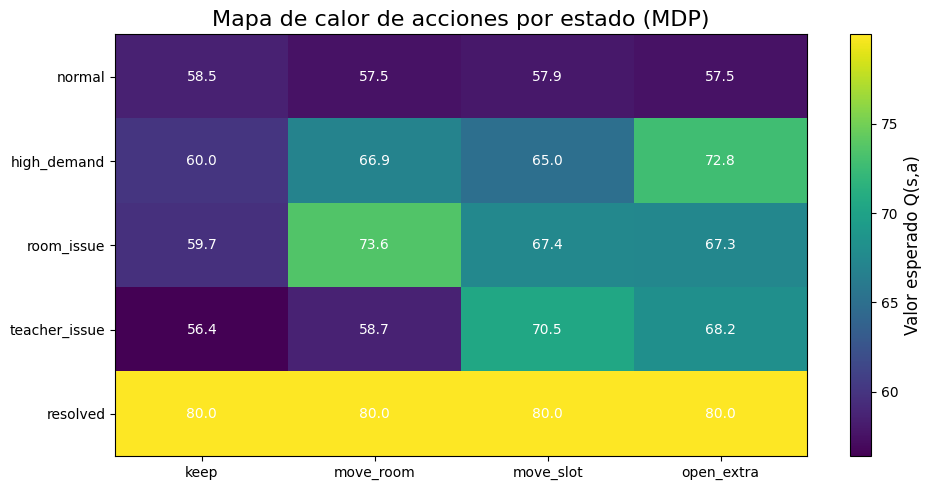

Política óptima estimada:
  -       normal: keep
  -  high_demand: open_extra
  -   room_issue: move_room
  - teacher_issue: move_slot
  -     resolved: keep


In [55]:
# ==========================================
# 16. Visualización del MDP
# ==========================================

plt.figure(figsize=(10, 5))
im = plt.imshow(Q_table.values.astype(float), aspect="auto", cmap="viridis")
plt.xticks(range(len(actions)), actions)
plt.yticks(range(len(states)), states)
plt.colorbar(im, label="Valor esperado Q(s,a)")
plt.title("Mapa de calor de acciones por estado (MDP)")
for i in range(len(states)):
    for j in range(len(actions)):
        plt.text(j, i, f"{Q_table.iloc[i, j]:.1f}", ha="center", va="center", color="white", fontsize=10)
plt.tight_layout()
plt.show()

print("Política óptima estimada:")
for s in states:
    print(f"  - {s:>12}: {policy[s]}")



# 12. Integración final del sistema

<div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:12px; margin-bottom:8px;">
  <div class="note-card"><b>Entrada</b><br/>OULAD + CSV enriquecidos</div>
  <div class="note-card"><b>Predicción</b><br/>Modelo supervisado → riesgo</div>
  <div class="note-card"><b>Planificación</b><br/>Demanda → CSP</div>
  <div class="note-card"><b>Adaptación</b><br/>Bayes + MDP</div>
</div>

## 12.1 Función objetivo global

Podemos resumir la lógica del proyecto como una función de utilidad compuesta:

$$
\mathcal{U} = \alpha \cdot \text{PredPerf}
+ \beta \cdot \text{SchedQuality}
- \delta \cdot \text{Risk}
+ \eta \cdot \text{MDPValue}
$$

donde:

- $\text{PredPerf}$ resume el desempeño del modelo predictivo,
- $\text{SchedQuality}$ resume la calidad y factibilidad del horario,
- $\text{Risk}$ es la probabilidad estimada de conflicto,
- $\text{MDPValue}$ representa la utilidad esperada de replanificación.

<div class="note-card">
<b>Lectura conceptual.</b> El proyecto no usa una sola técnica de IA; construye una <b>cadena de decisión inteligente</b> donde cada módulo aporta información estructurada al siguiente.
</div>


In [57]:
# ==========================================
# 17. Resumen ejecutivo automático
# ==========================================

# Mejor modelo
best_row = results_df.iloc[0]

# Resolver risk_df si existe; si no, construir uno básico desde schedule_df
if "risk_df" not in globals():
    if "schedule_df" in globals():
        risk_df = schedule_df.copy()

        # Si no existe conflict_risk, lo creamos con 0.0 como placeholder
        if "conflict_risk" not in risk_df.columns:
            risk_df["conflict_risk"] = 0.0
    else:
        raise NameError(
            "No existe 'risk_df' ni 'schedule_df'. "
            "Ejecuta primero la sección del módulo bayesiano / evaluación de riesgo."
        )

avg_conflict_risk = risk_df["conflict_risk"].mean()
high_risk_sections = (risk_df["conflict_risk"] >= 0.5).sum()

summary = pd.DataFrame({
    "Indicador": [
        "Observaciones usadas",
        "Mejor modelo",
        "F1 del mejor modelo",
        "AUC del mejor modelo",
        "Secciones programadas",
        "Backtracks del CSP",
        "Riesgo promedio de conflicto",
        "Secciones con riesgo >= 0.50",
    ],
    "Valor": [
        f"{len(X):,}",
        best_row["model"],
        round(float(best_row["f1"]), 4),
        round(float(best_row["roc_auc"]), 4) if pd.notna(best_row["roc_auc"]) else "N/A",
        len(schedule_df) if "schedule_df" in globals() else "N/A",
        counter["backtracks"] if "counter" in globals() else "N/A",
        round(float(avg_conflict_risk), 4),
        int(high_risk_sections),
    ]
})

display(summary)

,Indicador,Valor
0,Observaciones usadas,"32,593"
1,Mejor modelo,DecisionTree
2,F1 del mejor modelo,0.939
3,AUC del mejor modelo,0.9724
4,Secciones programadas,10
5,Backtracks del CSP,0
6,Riesgo promedio de conflicto,0.0
7,Secciones con riesgo >= 0.50,0



# 13. Conclusiones, limitaciones y trabajo futuro

<div class="note-card">
<b>Hallazgo central.</b> Este notebook muestra cómo un proyecto final de IA puede integrar
aprendizaje supervisado, búsqueda heurística, CSP, razonamiento probabilístico y MDP
en un mismo flujo de decisión aplicado a un problema realista de planificación académica.
</div>

## Conclusiones

1. **El módulo predictivo** convierte datos educativos en una señal útil para la planeación.
2. **El módulo CSP** demuestra cómo explotar estructura y restricciones para construir horarios factibles.
3. **El módulo probabilístico** incorpora incertidumbre explícita, algo clave en sistemas reales.
4. **El módulo MDP** transforma la solución en un agente capaz de decidir cómo reaccionar ante contingencias.

## Limitaciones

- OULAD no contiene información real de salones ni de docentes.
- La instancia operativa del scheduler es sintética, aunque derivada de la demanda del dataset.
- El modelo bayesiano y el MDP son simplificados para mantener el notebook claro y reproducible.



# 14. Uso de IA generativa, repositorio y referencias

<div class="note-card">
<b>Uso de IA generativa.</b> Este notebook fue diseñado con apoyo de IA para:
<ul>
  <li>estructurar la narrativa del proyecto,</li>
  <li>proponer una integración coherente entre módulos,</li>
  <li>mejorar estilo, visuales y documentación técnica.</li>
</ul>
La selección de variables, el modelado matemático, la lógica del CSP, el riesgo probabilístico y el MDP fueron adaptados y validados dentro del contexto del curso.
</div>
